In [88]:
import matplotlib.pyplot as plt
from pandas import DataFrame
import pandas as pd
import seaborn as sns

In [98]:
metrics = DataFrame(
    index=pd.Index(
        [
            'CNN - Webb (2026)',
            'Ensemble - Webb (2026)',
            'BiLSTM - Viana et al. (2023)',
            'CNN - Müller et al. (2022)',
            'Ensemble - Müller et al. (2022)',
        ],
        name='model'),
    data={
        'mean\nROC AUC': [
            .68,
            .66,
            .71,
            .68,
            .79,
        ],
        'mean\nrelative time \nin false warning': [
            .32,
            .38,
            .34,
            pd.NA,
            pd.NA,
        ],
        'mean\nsensitivity': [
            .71,
            .69,
            .73,
            pd.NA,
            pd.NA,
        ],
    },
)

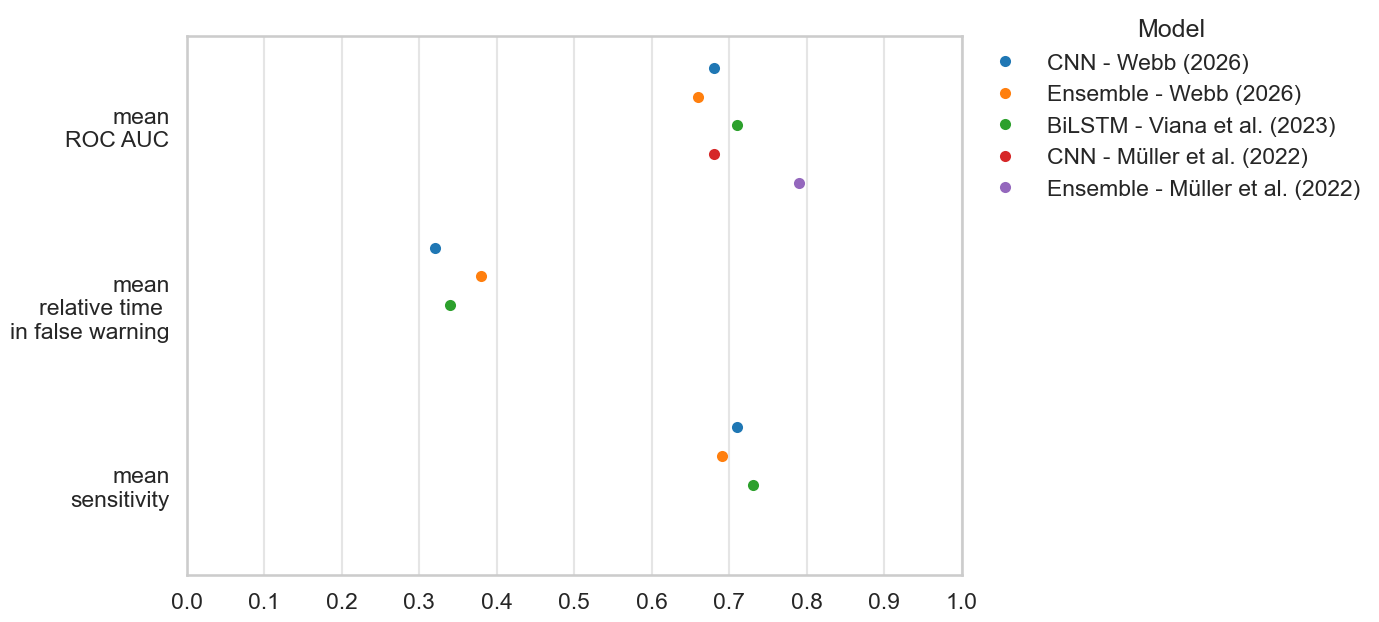

In [133]:
m_long = (
    metrics
    .reset_index()
    .melt(id_vars='model', var_name='metric', value_name='value')
    .dropna(subset=['value'])
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.set_style('whitegrid')
ax = sns.swarmplot(
    data=m_long,
    y='metric',
    x='value',
    hue='model',
    dodge=True,
    size=8,
    palette='tab10',
    # ax=ax,
)

ax.set_xlim([0, 1])
ax.set_ylabel(None)
ax.set_xlabel(None)
ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))

ax.legend(title='Model', bbox_to_anchor=(1, 1.07), loc='upper left', frameon=False)
plt.show()